In [1]:
import pandas as pd
import numpy as np
import os
import sys
notebook_dir = os.path.abspath(os.path.dirname(''))
project_root = os.path.dirname(notebook_dir)
sys.path.append(project_root)
import pandas as pd
from src.utils.db_utils import get_connection, execute_query


from src.features import team_level_features_class
from src.models import model
from src.utils.y_variable import build_spread_variable

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

In [2]:
nfl_model=model.NFLPredictor()
nfl_model.build_x_y_variable()

Successfully connected to the database!
Successfully connected to the database!
creating efficiency stats


100%|██████████| 5/5 [00:00<00:00, 294.91it/s]


building team stats


100%|██████████| 25/25 [00:23<00:00,  1.08it/s]


In [3]:
nfl_model.x_y

,home team defensive turnovers,away team defensive turnovers,home team offensive turnovers,away team offensive turnovers,home team defensive total_yards,away team defensive total_yards,home team offensive total_yards,away team offensive total_yards,home team defensive pass attempts,away team defensive pass attempts,...,away team offensive rushing efficiency_normalized,home team defensive third down efficiency_normalized,away team defensive third down efficiency_normalized,home team offensive third down efficiency_normalized,away team offensive third down efficiency_normalized,home team defensive team points_normalized,away team defensive team points_normalized,home team offensive team points_normalized,away team offensive team points_normalized,spread
2022_1_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2022_1_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
2022_1_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-16
2022_1_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2022_1_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024_20_1,1.411765,1.0,0.882353,0.888889,342.352941,324.555556,409.529412,368.555556,35.882353,28.555556,...,0.820783,-1.904785,0.046836,1.654829,1.315102,-0.925893,-0.019363,2.383509,1.248201,-14
2024_20_2,1.666667,1.222222,0.833333,0.777778,279.666667,348.444444,362.888889,329.166667,31.944444,32.333333,...,-0.923891,-1.046735,0.282563,0.218144,-0.907273,-1.836786,-0.316085,0.955388,-0.203135,6
2024_20_3,1.777778,0.944444,0.444444,0.611111,335.0,321.722222,365.333333,427.111111,33.388889,36.388889,...,3.083894,0.703959,0.124211,1.04149,1.846582,-0.686988,-0.686988,1.85929,1.73198,2
2024_21_0,1.684211,1.210526,0.789474,0.842105,286.105263,334.894737,362.210526,374.473684,32.578947,29.315789,...,0.724137,-1.019835,-0.059134,0.214791,1.189374,-1.813075,0.097323,0.967631,1.449517,32


In [4]:
# model_parameters={"n_estimators": [500,1000, 1500,2000],
#                      "max_depth": [1,3,5,10],
#                      "min_samples_leaf": [.01,.05,.1]}
# nfl_model.build_random_forest_model(model_parameters)

In [5]:
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 3, 4, 5],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4, 0.5]
}

nfl_model.build_xg_boost_model(param_dist)

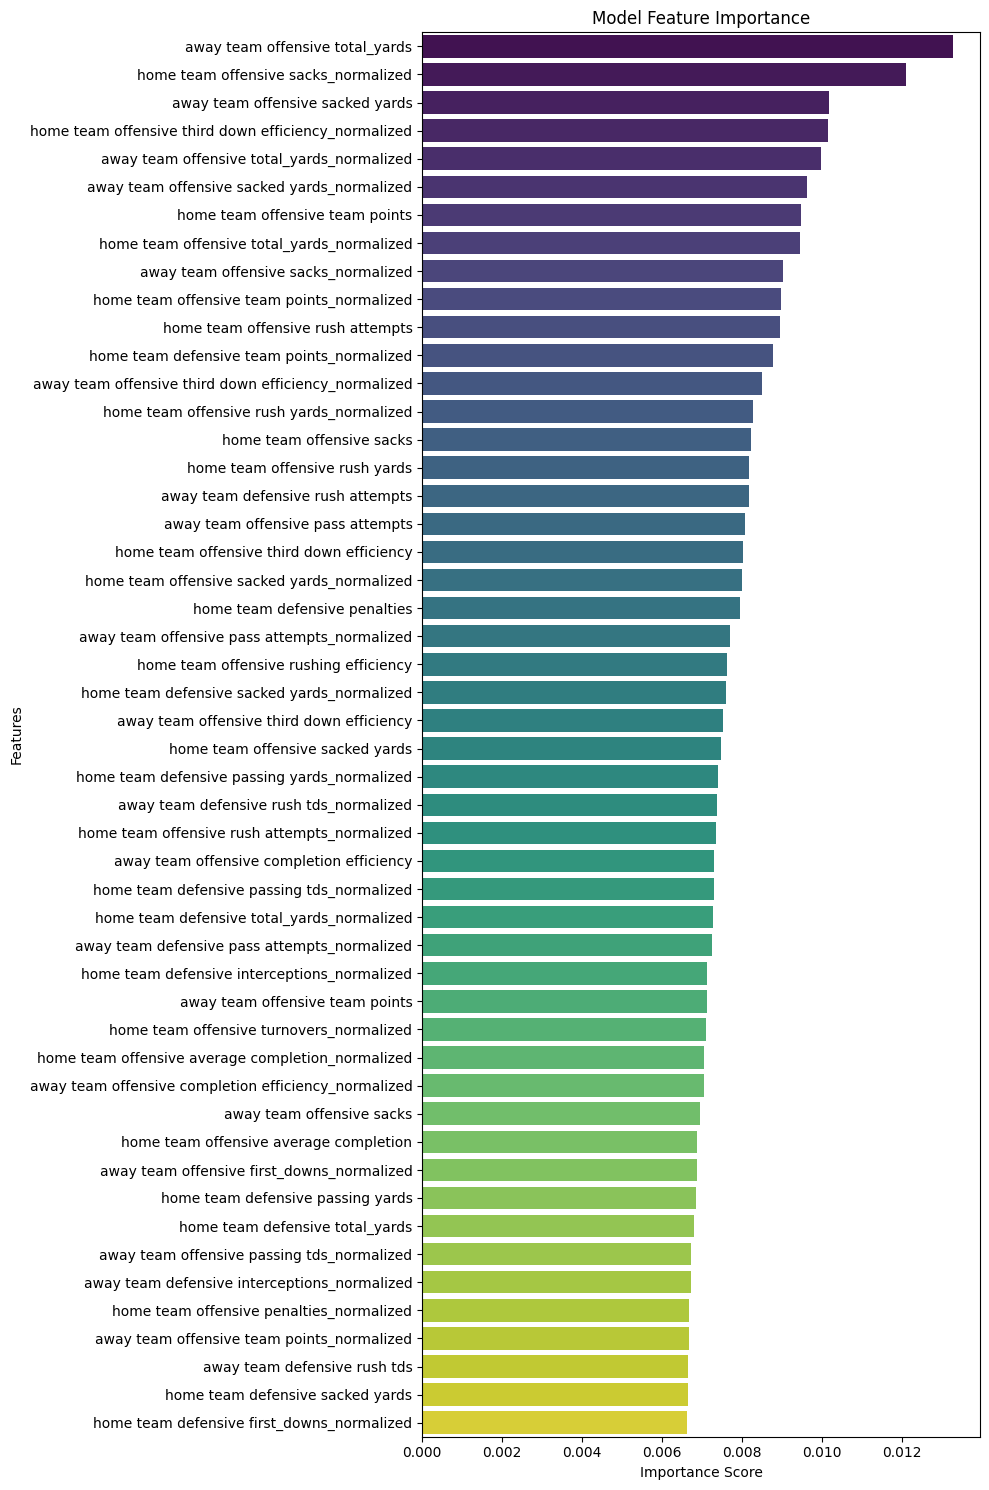

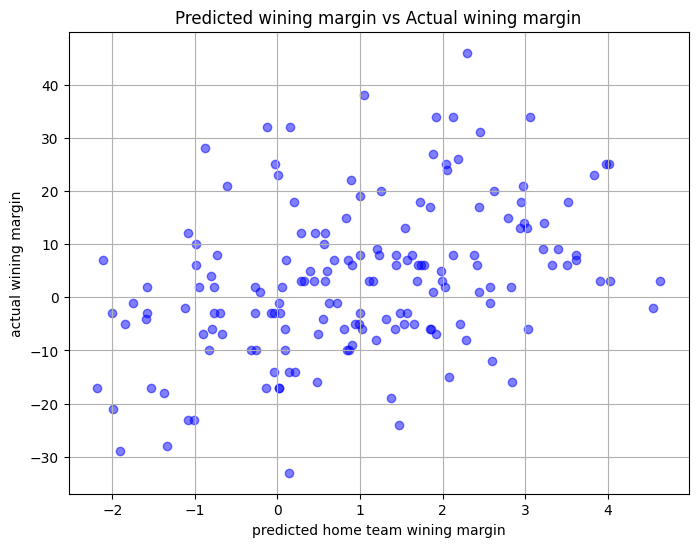

In [6]:
nfl_model.model_prediction(nfl_model.xg_model, x=nfl_model.x_test.to_numpy(),plot_feature_importance=True, plot_scatter=True)

In [14]:
current_game_stats=nfl_model.build_single_game_features("PHI", "KAN")

model=nfl_model.xg_model.fit(nfl_model.x_y.iloc[:,:-1].to_numpy(), nfl_model.x_y.iloc[:,-1])
model.predict(current_game_stats.iloc[:,:-1].to_numpy())

array([3.5566726], dtype=float32)

In [ ]:
model.predict(nfl_model.x_y.iloc[-2:,:-1].to_numpy())

array([1.0102892, 0.7356641], dtype=float32)